## Figures of the main manuscript

All figures are stored in PDF format in the folder `final_figures`.

### Figure 1 of the main manuscript

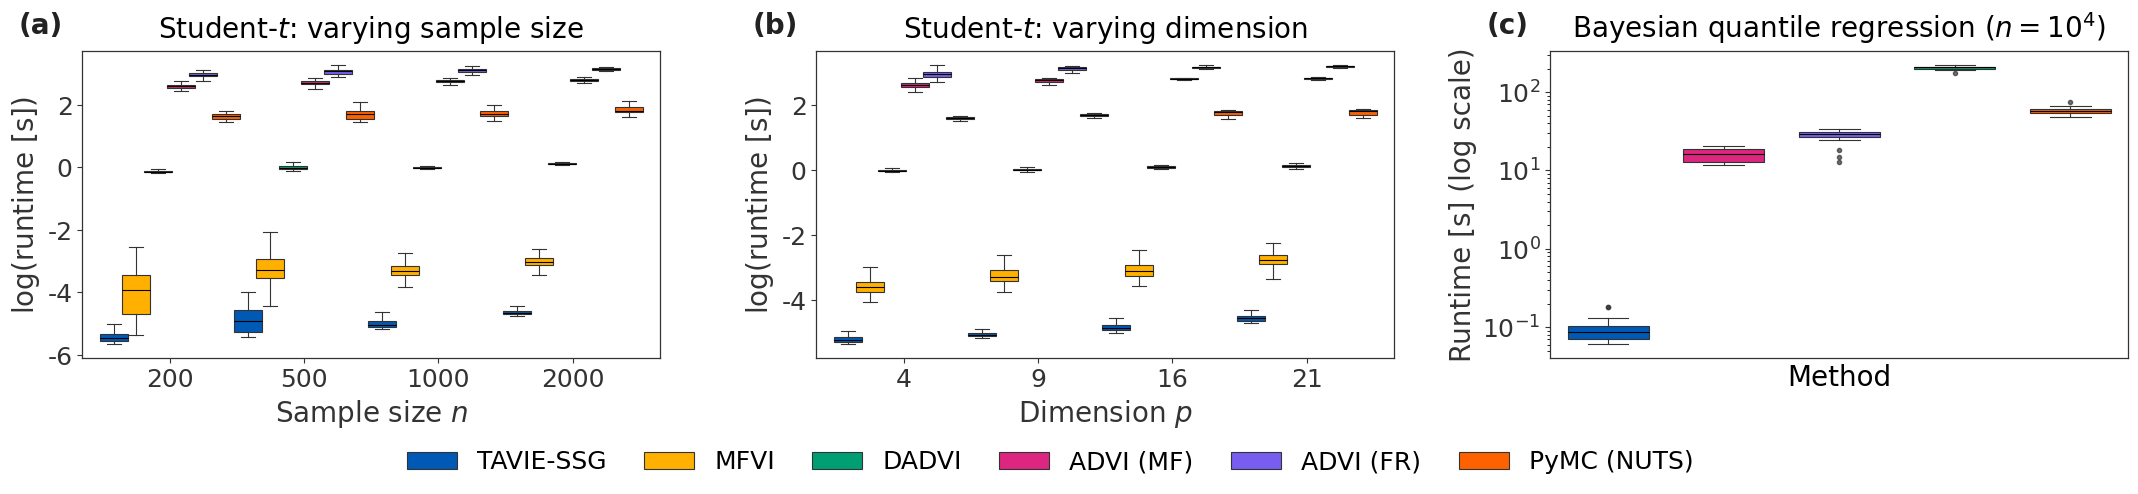

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# PATHS AND GLOBAL STYLE
# ============================================================

ROOT = Path.cwd()

assert (ROOT / "results_compete").exists(), (
    "Run final_figures.ipynb from the repository root."
)

OUTPUT_DIR = ROOT / "final_figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / "figure_1_main.pdf"

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# SHARED METHOD ORDER AND COLORS
# ============================================================

METHODS = [
    "TAVIE-SSG",
    "MFVI",
    "DADVI",
    "ADVI (MF)",
    "ADVI (FR)",
    "PyMC (NUTS)",
]

METHOD_COLORS = {
    "TAVIE-SSG": "#005AB5",    # vivid royal blue
    "MFVI": "#FFB000",         # golden amber
    "DADVI": "#009E73",        # emerald green
    "ADVI (MF)": "#DC267F",    # vibrant magenta
    "ADVI (FR)": "#785EF0",    # electric violet
    "PyMC (NUTS)": "#FE6100",  # vivid orange
}

RUNTIME_KEYS = {
    "TAVIE-SSG": "time_TAVIE",
    "MFVI": "time_MFVI",
    "DADVI": "time_DADVI",
    "ADVI (MF)": "time_ADVI_mf",
    "ADVI (FR)": "time_ADVI_fr",
    "PyMC (NUTS)": "time_NUTS",
}


# ============================================================
# LOAD STUDENT-t RESULTS FOR PANELS (a) AND (b)
# ============================================================

metrics_n = pd.read_pickle(
    ROOT / "results_compete/Student_metrics_multi_n_p_8.pkl"
)

metrics_p = pd.read_pickle(
    ROOT / "results_compete/Student_metrics_multi_p_n_1000.pkl"
)

sample_sizes = np.asarray(metrics_n["n"])
p_values = np.asarray(metrics_p["p"])

runtime_arrays_n = {
    method: np.asarray(metrics_n[key])
    for method, key in RUNTIME_KEYS.items()
}

runtime_arrays_p = {
    method: np.asarray(metrics_p[key])
    for method, key in RUNTIME_KEYS.items()
}

for method in METHODS:
    assert runtime_arrays_n[method].shape[0] == len(sample_sizes)
    assert runtime_arrays_p[method].shape[0] == len(p_values)


# ============================================================
# CENSUS QR RUNTIMES FOR PANEL (c)
# Statsmodels is excluded, as in the manuscript figure.
# ============================================================

CENSUS_RUNTIMES = {
    "TAVIE-SSG": [
        0.17975745900000106,
        0.10344854100003431,
        0.10472254199999043,
        0.100812332999908,
        0.08975741700010076,
        0.08647720900012246,
        0.07085958399989067,
        0.08094274999984918,
        0.06963725000014165,
        0.08788533400002052,
        0.06444874999988315,
        0.06913741699963794,
        0.061098874999970576,
        0.06359879199999341,
        0.08424204200036911,
        0.09837645799962047,
        0.10481037499994272,
        0.13240549999954965,
        0.18142979099957302,
    ],

    "ADVI (MF)": [
        18.503005166,
        17.129951249999976,
        20.35214795899992,
        19.11682466700006,
        19.495707332999928,
        18.318722292000075,
        18.77524625000001,
        19.30765137499975,
        13.461936667000373,
        16.356925583000248,
        12.691892958000153,
        13.935158791000049,
        11.616588832999696,
        12.140274042000328,
        12.725015625000196,
        12.334544250000363,
        19.31671083299989,
        16.06867175000025,
        12.859112708000794,
    ],

    "ADVI (FR)": [
        14.651485082999997,
        18.447061874999974,
        33.49736870800007,
        24.66567679100001,
        28.333677667000075,
        33.539521040999944,
        12.825355583000146,
        32.19524716700016,
        27.11407504099998,
        30.03818395899998,
        27.35170516700009,
        28.39662358300029,
        25.96842883399995,
        30.49529004199985,
        30.329209458999685,
        33.57137279200015,
        29.225641667000673,
        30.484952666999027,
        31.575826500000403,
    ],

    "DADVI": [
        196.069676625,
        210.036025,
        210.4256375,
        200.64027637499998,
        196.92681245899985,
        209.98926816699986,
        208.12886604100026,
        214.59474233299989,
        212.95861675000015,
        208.06786754199993,
        190.697985625,
        190.5869655409997,
        177.24406666599998,
        213.9769369999999,
        200.8044337499996,
        209.1613290409996,
        220.4271401670003,
        200.45342866600004,
        204.61888566700054,
    ],

    "PyMC (NUTS)": [
        49.76014900000001,
        67.1513175419999,
        61.60349479199999,
        57.652351082999985,
        60.597908167000014,
        59.87426487499988,
        49.128150832999836,
        60.898439083000085,
        52.70971062499984,
        48.718330416999834,
        58.06466887500028,
        54.7333529589996,
        52.01612429199986,
        57.50917345800008,
        57.26772250000067,
        65.1580214579999,
        75.5510597499997,
        63.81477799999993,
        56.59357766700032,
    ],
}

CENSUS_METHODS = [
    "TAVIE-SSG",
    "ADVI (MF)",
    "ADVI (FR)",
    "DADVI",
    "PyMC (NUTS)",
]

assert all(
    len(CENSUS_RUNTIMES[method]) == 19
    for method in CENSUS_METHODS
)


# ============================================================
# PLOTTING SETTINGS
# ============================================================

EPS = 1e-16
GROUP_SPACING = 2.4
METHOD_STEP = 0.40
BOX_WIDTH = 0.50

median_style = {
    "color": "black",
    "linewidth": 0.8,
}

whisker_style = {
    "color": "#333333",
    "linewidth": 0.8,
}

cap_style = {
    "color": "#333333",
    "linewidth": 0.8,
}


def style_axis(ax):
    ax.set_facecolor("white")

    ax.tick_params(
        axis="both",
        colors="#333333",
        labelsize=18,
    )

    for spine in ax.spines.values():
        spine.set_color("#333333")
        spine.set_linewidth(0.9)


def add_student_runtime_panel(
    ax,
    runtime_arrays,
    x_values,
    xlabel,
):
    """
    Draw one Student-t runtime panel.

    The original figure applies the natural logarithm to each
    recorded runtime before constructing the boxplots.
    """
    centers = np.arange(len(x_values)) * GROUP_SPACING

    for j, method in enumerate(METHODS):
        arr = np.asarray(runtime_arrays[method])

        data = [
            np.log(np.clip(arr[i, :], EPS, None))
            for i in range(len(x_values))
        ]

        positions = (
            centers
            + (j - (len(METHODS) - 1) / 2) * METHOD_STEP
        )

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=BOX_WIDTH,
            patch_artist=True,
            showfliers=False,
            medianprops=median_style,
            whiskerprops=whisker_style,
            capprops=cap_style,
        )

        for box in bp["boxes"]:
            box.set(
                facecolor=METHOD_COLORS[method],
                edgecolor="#333333",
                linewidth=0.8,
                alpha=1.0,
            )

    ax.set_xticks(centers)
    ax.set_xticklabels(x_values)

    ax.set_xlabel(
        xlabel,
        fontsize=20,
        color="#333333",
    )

    ax.set_ylabel(
        r"$\log(\mathrm{runtime}\ [\mathrm{s}])$",
        fontsize=20,
        color="#333333",
    )

    ax.set_xlim(
        centers[0] - GROUP_SPACING * 0.65,
        centers[-1] + GROUP_SPACING * 0.65,
    )

    style_axis(ax)


# ============================================================
# CREATE THE 1 x 3 COMPOSITE
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 4.2),
    facecolor="white",
)


# ------------------------------------------------------------
# Panel (a): Student-t runtime versus sample size
# ------------------------------------------------------------

add_student_runtime_panel(
    ax=axes[0],
    runtime_arrays=runtime_arrays_n,
    x_values=sample_sizes,
    xlabel=r"Sample size $n$",
)

axes[0].set_title(
    r"Student-$t$: varying sample size",
    fontsize=20,
    pad=10,
)


# ------------------------------------------------------------
# Panel (b): Student-t runtime versus dimension
# ------------------------------------------------------------

add_student_runtime_panel(
    ax=axes[1],
    runtime_arrays=runtime_arrays_p,
    x_values=np.array(p_values) + 1,
    xlabel=r"Dimension $p$",
)

axes[1].set_title(
    r"Student-$t$: varying dimension",
    fontsize=20,
    pad=10,
)


# ------------------------------------------------------------
# Panel (c): Census QR runtime comparison
# ------------------------------------------------------------

ax = axes[2]

census_data = [
    np.asarray(CENSUS_RUNTIMES[method])
    for method in CENSUS_METHODS
]

bp = ax.boxplot(
    census_data,
    widths=0.70,
    patch_artist=True,
    showfliers=True,
    medianprops=median_style,
    whiskerprops=whisker_style,
    capprops=cap_style,
    flierprops={
        "marker": "o",
        "markersize": 3,
        "markerfacecolor": "#333333",
        "markeredgecolor": "#333333",
        "alpha": 0.7,
    },
)

for box, method in zip(bp["boxes"], CENSUS_METHODS):
    box.set(
        facecolor=METHOD_COLORS[method],
        edgecolor="#333333",
        linewidth=0.8,
        alpha=1.0,
    )

ax.set_yscale("log")

# The methods are identified by the shared legend, so the
# third panel does not need x-axis tick marks or labels.
ax.set_xticks([])
ax.set_xlabel("Method", fontsize=20)

ax.set_ylabel(
    r"Runtime [s] (log scale)",
    fontsize=20,
    color="#333333",
)

ax.set_title(
    r"Bayesian quantile regression ($n=10^4$)",
    fontsize=20,
    pad=10,
)

style_axis(ax)


# ============================================================
# PANEL LABELS
# ============================================================

for ax, label in zip(axes, ["(a)", "(b)", "(c)"]):
    ax.text(
        -0.11,
        1.04,
        label,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold",
        va="bottom",
        ha="left",
        color="#222222",
    )


# ============================================================
# ONE SHARED LEGEND FOR ALL THREE PANELS
# ============================================================

legend_handles = [
    Patch(
        facecolor=METHOD_COLORS[method],
        edgecolor="#333333",
        linewidth=0.8,
        label=method,
    )
    for method in METHODS
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(METHODS),
    frameon=False,
    fontsize=18,
    bbox_to_anchor=(0.5, -0.18),
    columnspacing=1.5,
    handlelength=2.0,
)


# ============================================================
# FINAL LAYOUT AND PDF EXPORT
# ============================================================

fig.subplots_adjust(
    left=0.06,
    right=0.99,
    top=0.88,
    bottom=0.15,
    wspace=0.27,
)

fig.savefig(
    OUTPUT_PATH,
    format="pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

### Figure 2 of the main manuscript

Student-t fitted values
  xi_1_star   = 1.282847058188380
  zeta_1_star = 1.271078480694209

Negative-Binomial fitted values
  xi_1_star   = 3.755348537768828
  zeta_1_star = 3.749143992653644
  y_1         = 0
  m_1         = 10


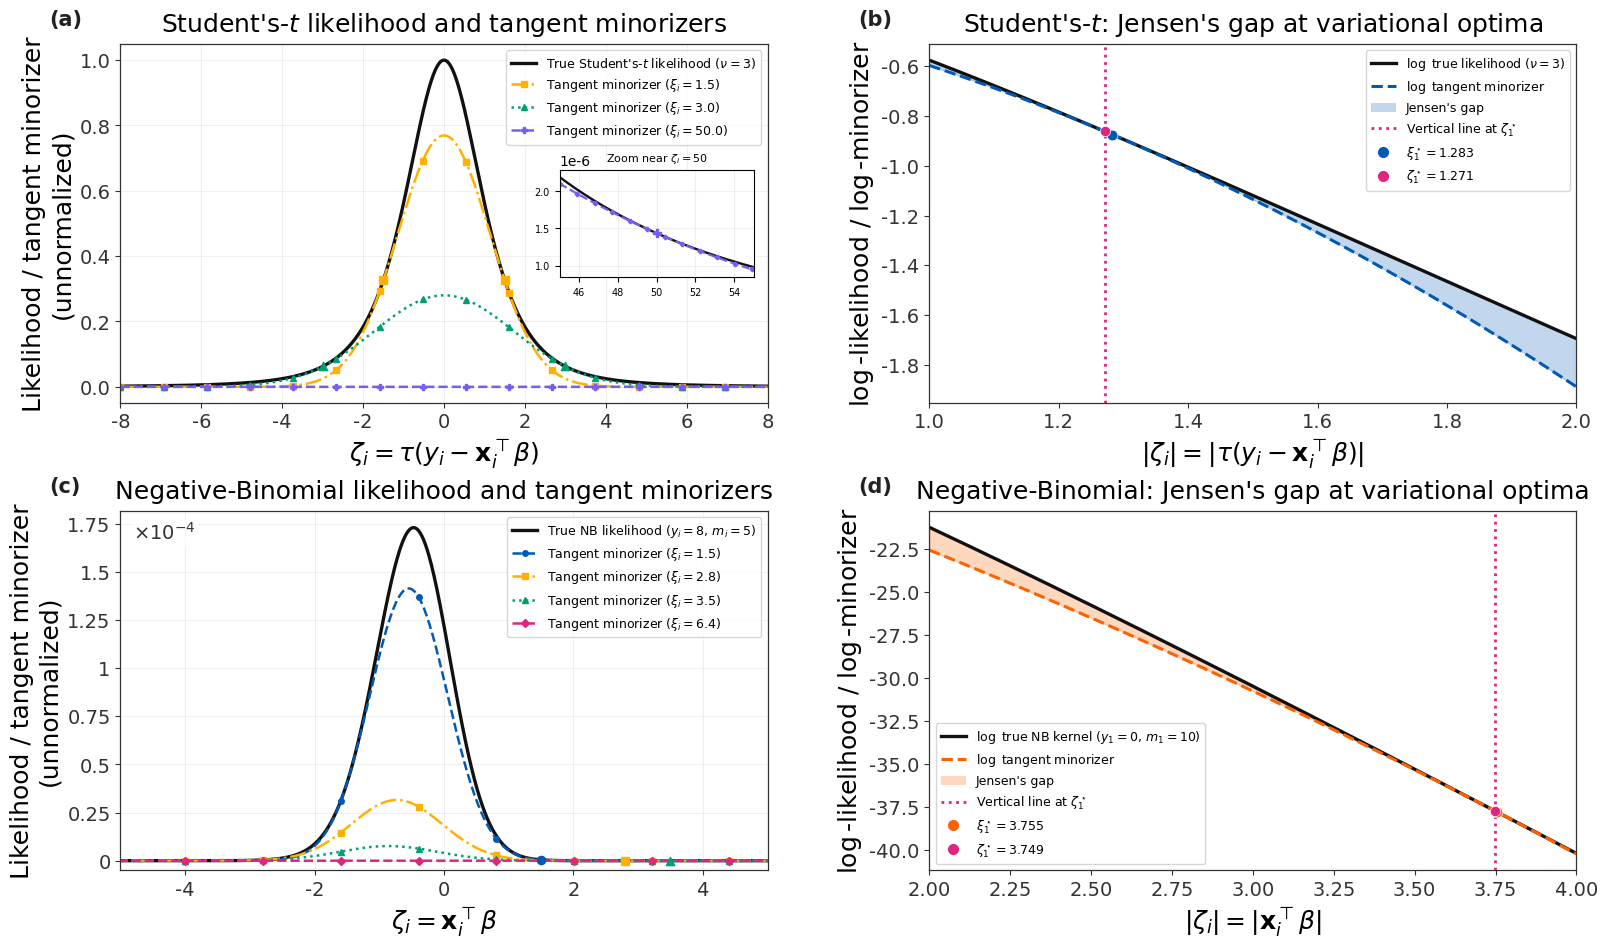

In [1]:
from pathlib import Path

from matplotlib.ticker import FuncFormatter

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from TAVIE import TAVIE_loc_scale, TAVIE_type_II


# ============================================================
# PATHS AND GLOBAL STYLE
# ============================================================

ROOT = Path.cwd()

assert (ROOT / "TAVIE").exists(), (
    "Run final_figures.ipynb from the repository root."
)

OUTPUT_DIR = ROOT / "final_figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / "figure_2_main.pdf"

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# SHARED COLORS
# ============================================================

BLACK = "#111111"
BLUE = "#005AB5"
GOLD = "#FFB000"
GREEN = "#009E73"
MAGENTA = "#DC267F"
VIOLET = "#785EF0"
ORANGE = "#FE6100"
AXIS_COLOR = "#333333"

TANGENT_COLORS = [
    # BLUE,
    GOLD,
    GREEN,
    # MAGENTA,
    VIOLET,
]


# ============================================================
# GENERAL AXIS STYLE
# ============================================================

def style_axis(ax, tick_size=14):
    ax.set_facecolor("white")

    ax.tick_params(
        axis="x",
        colors=AXIS_COLOR,
        labelsize=tick_size,
    )

    ax.tick_params(
        axis="y",
        colors=AXIS_COLOR,
        labelsize=tick_size,
    )

    for spine in ax.spines.values():
        spine.set_color(AXIS_COLOR)
        spine.set_linewidth(0.9)


# ============================================================
# STUDENT-t FUNCTIONS
# ============================================================

def student_kernel(zeta, nu=3.0):
    """Unnormalized Student-t likelihood kernel."""
    return (
        1.0 + np.asarray(zeta) ** 2 / nu
    ) ** (-(nu + 1.0) / 2.0)


def student_h(t, nu=3.0):
    return -0.5 * (nu + 1.0) * np.log(
        1.0 + np.asarray(t) / nu
    )


def student_A(xi, nu=3.0):
    return -(nu + 1.0) / (
        2.0 * (nu + np.asarray(xi) ** 2)
    )


def student_gamma(xi, nu=3.0):
    xi = np.asarray(xi)

    return (
        student_h(xi**2, nu=nu)
        - xi**2 * student_A(xi, nu=nu)
    )


def student_tangent_minorizer(zeta, xi, nu=3.0):
    return np.exp(
        student_A(xi, nu=nu) * np.asarray(zeta) ** 2
        + student_gamma(xi, nu=nu)
    )


def log_student_kernel(zeta, nu=3.0):
    return -0.5 * (nu + 1.0) * np.log(
        1.0 + np.asarray(zeta) ** 2 / nu
    )


def log_student_tangent_minorizer(zeta, xi, nu=3.0):
    return (
        student_A(xi, nu=nu) * np.asarray(zeta) ** 2
        + student_gamma(xi, nu=nu)
    )


# ============================================================
# NEGATIVE-BINOMIAL FUNCTIONS
# ============================================================

def negbin_kernel(zeta, y, m):
    """
    Unnormalized Negative-Binomial likelihood kernel used in
    the tangent-minorizer panel.
    """
    zeta = np.asarray(zeta)

    return (
        np.exp(m * zeta)
        / (1.0 + np.exp(zeta)) ** (y + m)
    )


def negbin_A(xi):
    """
    A(xi) for the Negative-Binomial Type II SSG likelihood.
    """
    xi_array = np.asarray(xi, dtype=float)

    if xi_array.ndim == 0:
        xi_value = float(xi_array)

        if np.isclose(xi_value, 0.0):
            return -1.0 / 8.0

        return (
            -np.tanh(xi_value / 2.0)
            / (4.0 * xi_value)
        )

    out = np.empty_like(xi_array)
    small = np.isclose(xi_array, 0.0)

    out[small] = -1.0 / 8.0
    out[~small] = (
        -np.tanh(xi_array[~small] / 2.0)
        / (4.0 * xi_array[~small])
    )

    return out


def negbin_h_from_xi(xi):
    return -np.log(
        2.0 * np.cosh(np.asarray(xi) / 2.0)
    )


def negbin_gamma(xi):
    xi = np.asarray(xi)

    return (
        negbin_h_from_xi(xi)
        - xi**2 * negbin_A(xi)
    )


def negbin_tangent_minorizer(zeta, xi, y, m):
    zeta = np.asarray(zeta)

    linear_coefficient = 0.5 * (m - y)
    quadratic_coefficient = (y + m) * negbin_A(xi)
    constant_term = (y + m) * negbin_gamma(xi)

    return np.exp(
        linear_coefficient * zeta
        + quadratic_coefficient * zeta**2
        + constant_term
    )


def negbin_h(t):
    return -np.log(
        2.0 * np.cosh(np.sqrt(np.asarray(t)) / 2.0)
    )


def log_negbin_kernel(zeta, y_i, m_i):
    """
    Log-kernel used in the Jensen-gap panel, matching
    Section_C_gaps.ipynb.
    """
    zeta = np.asarray(zeta)

    return (
        0.5 * (y_i - m_i) * zeta
        + (y_i + m_i) * negbin_h(zeta**2)
    )


def log_negbin_tangent_minorizer(
    zeta,
    xi,
    y_i,
    m_i,
):
    zeta = np.asarray(zeta)

    return (
        0.5 * (y_i - m_i) * zeta
        + (y_i + m_i)
        * (
            negbin_A(xi) * zeta**2
            + negbin_gamma(xi)
        )
    )


# ============================================================
# FIT THE STUDENT-t MODEL FOR THE TOP-RIGHT PANEL
# ============================================================

def fit_student_model_for_jensen_gap():
    n = 500
    p = 8
    tau2_true = 3.0
    df = 3

    np.random.seed(123)

    X = np.random.normal(size=(n, p))

    beta_true = np.random.normal(
        loc=0.0,
        scale=1.0,
        size=p + 1,
    )

    error = (
        np.random.standard_t(df=df, size=n)
        / np.sqrt(tau2_true)
    )

    y = (
        beta_true[0]
        + X @ beta_true[1:]
        + error
    )

    model = TAVIE_loc_scale(
        family="student",
        fit_intercept=True,
    )

    model.fit(
        X,
        y,
        nu=df,
        verbose=False,
    )

    xi_1_star = float(
        model.fitted_values["xi"][0]
    )

    beta_star, tau2_star = model.get_TAVIE_means(
        verbose=False
    )

    residuals = (
        y
        - (
            beta_star[0]
            + X @ beta_star[1:]
        )
    )

    zeta_1_star = float(
        np.abs(
            np.sqrt(tau2_star) * residuals[0]
        )
    )

    return {
        "df": df,
        "xi_1_star": xi_1_star,
        "zeta_1_star": zeta_1_star,
    }


# ============================================================
# FIT THE NEGATIVE-BINOMIAL MODEL FOR THE BOTTOM-RIGHT PANEL
# ============================================================

def fit_negbin_model_for_jensen_gap():
    n = 200
    p = 8
    m = 10

    np.random.seed(123)

    X = np.random.normal(size=(n, p))

    beta_true = np.random.normal(
        loc=0.0,
        scale=0.5,
        size=p + 1,
    )

    eta_true = (
        beta_true[0]
        + X @ beta_true[1:]
    )

    mu_true = np.exp(eta_true)

    # NumPy parameterization:
    # Y ~ NB(size=m, probability=m/(m+mu)).
    probability = m / (m + mu_true)

    y = np.random.negative_binomial(
        n=m,
        p=probability,
        size=n,
    )

    model = TAVIE_type_II(
        family="negbin",
        fit_intercept=True,
    )

    model.fit(
        X,
        y,
        r=m,
        verbose=False,
    )

    xi_1_star = float(
        model.fitted_values["xi"][0]
    )

    beta_star = model.get_TAVIE_means(
        verbose=False
    )

    eta_star = (
        beta_star[0]
        + X @ beta_star[1:]
    )

    zeta_1_star = float(eta_star[0])

    return {
        "xi_1_star": xi_1_star,
        "zeta_1_star": zeta_1_star,
        "y_1": int(y[0]),
        "m_1": int(m),
    }


# ============================================================
# PANEL (a): STUDENT-t TANGENT MINORIZERS
# ============================================================

def plot_student_tangent_panel(ax):
    nu = 3.0

    zeta = np.linspace(-8.0, 8.0, 1200)

    xi_values = [
        # 0.5,
        1.5,
        3.0,
        # 7.0,
        50.0,
    ]

    line_styles = [
        # "--",
        "-.",
        ":",
        # "--",
        "--",
    ]

    markers = [
        # "o",
        "s",
        "^",
        # "D",
        "P",
    ]

    ax.plot(
        zeta,
        student_kernel(zeta, nu=nu),
        color=BLACK,
        linewidth=2.4,
        label=rf"True Student's-$t$ likelihood ($\nu={int(nu)}$)",
    )

    for xi, color, line_style, marker in zip(
        xi_values,
        TANGENT_COLORS,
        line_styles,
        markers,
    ):
        phi_values = student_tangent_minorizer(
            zeta,
            xi,
            nu=nu,
        )

        ax.plot(
            zeta,
            phi_values,
            color=color,
            linestyle=line_style,
            linewidth=1.8,
            marker=marker,
            markevery=80,
            markersize=4,
            label=rf"Tangent minorizer ($\xi_i={xi}$)",
        )

        y_tangent = student_kernel(
            np.array([xi]),
            nu=nu,
        )[0]

        ax.scatter(
            [xi, -xi],
            [y_tangent, y_tangent],
            color=color,
            marker=marker,
            s=35,
            zorder=5,
        )

    ax.set_xlabel(
        r"$\zeta_i=\tau(y_i-\mathbf{x}_i^\top\beta)$",
        fontsize=18,
    )

    ax.set_ylabel(
        "Likelihood / tangent minorizer\n(unnormalized)",
        fontsize=18,
    )

    ax.set_title(
        r"Student's-$t$ likelihood and tangent minorizers",
        fontsize=18,
        pad=9,
    )

    ax.set_xlim(-8.0, 8.0)
    ax.set_ylim(bottom=-0.05)
    ax.grid(alpha=0.20)

    ax.legend(
        frameon=True,
        fontsize=9,
        loc="upper right",
    )

    style_axis(ax)

    # --------------------------------------------------------
    # Inset around zeta_i = 50
    # --------------------------------------------------------

    xi_zoom = 50.0
    zeta_zoom = np.linspace(45.0, 55.0, 500)

    true_zoom = student_kernel(
        zeta_zoom,
        nu=nu,
    )

    tangent_zoom = student_tangent_minorizer(
        zeta_zoom,
        xi_zoom,
        nu=nu,
    )

    y_zoom_tangent = student_kernel(
        np.array([xi_zoom]),
        nu=nu,
    )[0]

    ax_inset = inset_axes(
        ax,
        width="30%",
        height="30%",
        loc="center right",
        borderpad=1.0,
    )

    ax_inset.plot(
        zeta_zoom,
        true_zoom,
        color=BLACK,
        linewidth=1.7,
    )

    ax_inset.plot(
        zeta_zoom,
        tangent_zoom,
        color=VIOLET,
        linestyle="--",
        linewidth=1.6,
        marker="P",
        markevery=45,
        markersize=3,
    )

    ax_inset.scatter(
        [xi_zoom],
        [y_zoom_tangent],
        color=VIOLET,
        marker="P",
        s=28,
        zorder=5,
    )

    ax_inset.set_title(
        r"Zoom near $\zeta_i=50$",
        fontsize=8,
    )

    ax_inset.set_xlim(45.0, 55.0)

    ymin = min(
        true_zoom.min(),
        tangent_zoom.min(),
    )

    ymax = max(
        true_zoom.max(),
        tangent_zoom.max(),
    )

    pad = (
        0.08 * (ymax - ymin)
        if ymax > ymin
        else 1e-8
    )

    ax_inset.set_ylim(
        ymin - pad,
        ymax + pad,
    )

    ax_inset.grid(alpha=0.20)
    ax_inset.tick_params(labelsize=7)


# ============================================================
# PANEL (b): STUDENT-t JENSEN GAP
# ============================================================

def plot_student_jensen_panel(ax, fit_results):
    df = fit_results["df"]
    xi_1_star = fit_results["xi_1_star"]
    zeta_1_star = fit_results["zeta_1_star"]

    xleft = 1.0
    xright = 2.0

    zeta = np.linspace(
        xleft,
        xright,
        1500,
    )

    log_true = log_student_kernel(
        zeta,
        nu=df,
    )

    log_minorizer = log_student_tangent_minorizer(
        zeta,
        xi_1_star,
        nu=df,
    )

    y_tangent = log_student_kernel(
        np.array([xi_1_star]),
        nu=df,
    )[0]

    y_zeta = log_student_kernel(
        np.array([zeta_1_star]),
        nu=df,
    )[0]

    ax.plot(
        zeta,
        log_true,
        color=BLACK,
        linewidth=2.4,
    )

    ax.plot(
        zeta,
        log_minorizer,
        color=BLUE,
        linestyle="--",
        linewidth=2.2,
    )

    ax.fill_between(
        zeta,
        log_minorizer,
        log_true,
        where=(log_true >= log_minorizer),
        color=BLUE,
        alpha=0.24,
        interpolate=True,
    )

    ax.scatter(
        [xi_1_star],
        [y_tangent],
        color=BLUE,
        edgecolor="white",
        linewidth=0.5,
        s=60,
        zorder=5,
    )

    ax.axvline(
        x=zeta_1_star,
        color=MAGENTA,
        linestyle=":",
        linewidth=2.0,
    )

    ax.scatter(
        [zeta_1_star],
        [y_zeta],
        color=MAGENTA,
        edgecolor="white",
        linewidth=0.5,
        s=55,
        zorder=6,
    )

    ax.set_xlabel(
        r"$|\zeta_i|=|\tau(y_i-\mathbf{x}_i^\top\beta)|$",
        fontsize=18,
    )

    ax.set_ylabel(
        r"$\log$-likelihood / $\log$-minorizer",
        fontsize=18,
    )

    ax.set_title(
        r"Student's-$t$: Jensen's gap at variational optima",
        fontsize=18,
        pad=9,
    )

    ax.set_xlim(xleft, xright)

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=BLACK,
            linewidth=2.4,
            label=rf"$\log$ true likelihood $(\nu={df})$",
        ),
        Line2D(
            [0],
            [0],
            color=BLUE,
            linewidth=2.2,
            linestyle="--",
            label=r"$\log$ tangent minorizer",
        ),
        Patch(
            facecolor=BLUE,
            alpha=0.24,
            edgecolor="none",
            label="Jensen's gap",
        ),
        Line2D(
            [0],
            [0],
            color=MAGENTA,
            linewidth=2.0,
            linestyle=":",
            label=r"Vertical line at $\zeta_1^\star$",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color=BLUE,
            linestyle="None",
            markersize=7,
            label=rf"$\xi_1^\star={xi_1_star:.3f}$",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color=MAGENTA,
            linestyle="None",
            markersize=7,
            label=rf"$\zeta_1^\star={zeta_1_star:.3f}$",
        ),
    ]

    ax.legend(
        handles=legend_handles,
        loc="best",
        fontsize=9,
        frameon=True,
    )

    style_axis(ax)


# ============================================================
# PANEL (c): NEGATIVE-BINOMIAL TANGENT MINORIZERS
# ============================================================

def plot_negbin_tangent_panel(ax):
    y_i = 8.0
    m_i = 5.0

    zeta = np.linspace(
        -10.0,
        10.0,
        1500,
    )

    xi_values = [
        1.5,
        2.8,
        3.5,
        6.4,
    ]

    colors = [
        BLUE,
        GOLD,
        GREEN,
        MAGENTA,
    ]

    line_styles = [
        "--",
        "-.",
        ":",
        "--",
    ]

    markers = [
        "o",
        "s",
        "^",
        "D",
    ]

    ax.plot(
        zeta,
        negbin_kernel(
            zeta,
            y=y_i,
            m=m_i,
        ),
        color=BLACK,
        linewidth=2.4,
        label=(
            rf"True NB likelihood "
            rf"($y_i={int(y_i)},\,m_i={int(m_i)}$)"
        ),
    )

    for xi, color, line_style, marker in zip(
        xi_values,
        colors,
        line_styles,
        markers,
    ):
        phi_values = negbin_tangent_minorizer(
            zeta,
            xi,
            y=y_i,
            m=m_i,
        )

        ax.plot(
            zeta,
            phi_values,
            color=color,
            linestyle=line_style,
            linewidth=1.8,
            marker=marker,
            markevery=90,
            markersize=4,
            label=rf"Tangent minorizer ($\xi_i={xi}$)",
        )

        y_tangent = negbin_kernel(
            np.array([xi]),
            y=y_i,
            m=m_i,
        )[0]

        ax.scatter(
            [xi],
            [y_tangent],
            color=color,
            marker=marker,
            s=35,
            zorder=5,
        )

    ax.set_xlabel(
        r"$\zeta_i=\mathbf{x}_i^\top\beta$",
        fontsize=18,
    )

    ax.set_ylabel(
        "Likelihood / tangent minorizer\n(unnormalized)",
        fontsize=18,
    )

    ax.set_title(
        "Negative-Binomial likelihood and tangent minorizers",
        fontsize=18,
        pad=9,
    )

    ax.set_xlim(-5.0, 5.0)
    ax.set_ylim(bottom=-0.000005)
    # Show y ticks in units of 10^{-4}.
    y_scale = 1e-4

    ax.yaxis.set_major_formatter(
        FuncFormatter(
            lambda value, position: f"{value / y_scale:g}"
        )
    )

    # Put the multiplier inside the upper-left corner of panel (c).
    ax.text(
        0.02,
        0.97,
        r"$\times 10^{-4}$",
        transform=ax.transAxes,
        fontsize=14,
        ha="left",
        va="top",
        color=AXIS_COLOR,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.80,
            "pad": 1.5,
        },
        zorder=10,
    )

    ax.grid(alpha=0.20)

    ax.legend(
        frameon=True,
        fontsize=9,
        loc="upper right",
    )

    style_axis(ax)


# ============================================================
# PANEL (d): NEGATIVE-BINOMIAL JENSEN GAP
# ============================================================

def plot_negbin_jensen_panel(ax, fit_results):
    xi_1_star = fit_results["xi_1_star"]
    zeta_1_star = fit_results["zeta_1_star"]
    y_1 = fit_results["y_1"]
    m_1 = fit_results["m_1"]

    xleft = 2.0
    xright = 4.0

    zeta = np.linspace(
        xleft,
        xright,
        2000,
    )

    log_true = log_negbin_kernel(
        zeta,
        y_i=y_1,
        m_i=m_1,
    )

    log_minorizer = log_negbin_tangent_minorizer(
        zeta,
        xi=xi_1_star,
        y_i=y_1,
        m_i=m_1,
    )

    y_tangent = log_negbin_kernel(
        np.array([xi_1_star]),
        y_i=y_1,
        m_i=m_1,
    )[0]

    y_zeta = log_negbin_kernel(
        np.array([zeta_1_star]),
        y_i=y_1,
        m_i=m_1,
    )[0]

    ax.plot(
        zeta,
        log_true,
        color=BLACK,
        linewidth=2.4,
    )

    ax.plot(
        zeta,
        log_minorizer,
        color=ORANGE,
        linestyle="--",
        linewidth=2.2,
    )

    ax.fill_between(
        zeta,
        log_minorizer,
        log_true,
        where=(log_true >= log_minorizer),
        color=ORANGE,
        alpha=0.25,
        interpolate=True,
    )

    ax.scatter(
        [xi_1_star],
        [y_tangent],
        color=ORANGE,
        edgecolor="white",
        linewidth=0.5,
        s=60,
        zorder=5,
    )

    ax.axvline(
        x=zeta_1_star,
        color=MAGENTA,
        linestyle=":",
        linewidth=2.0,
    )

    ax.scatter(
        [zeta_1_star],
        [y_zeta],
        color=MAGENTA,
        edgecolor="white",
        linewidth=0.5,
        s=55,
        zorder=6,
    )

    ax.set_xlabel(
        r"$|\zeta_i|=|\mathbf{x}_i^\top\beta|$",
        fontsize=18,
    )

    ax.set_ylabel(
        r"$\log$-likelihood / $\log$-minorizer",
        fontsize=18,
    )

    ax.set_title(
        "Negative-Binomial: Jensen's gap at variational optima",
        fontsize=18,
        pad=9,
    )

    ax.set_xlim(xleft, xright)

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=BLACK,
            linewidth=2.4,
            label=(
                rf"$\log$ true NB kernel "
                rf"$(y_1={y_1},\,m_1={m_1})$"
            ),
        ),
        Line2D(
            [0],
            [0],
            color=ORANGE,
            linewidth=2.2,
            linestyle="--",
            label=r"$\log$ tangent minorizer",
        ),
        Patch(
            facecolor=ORANGE,
            alpha=0.25,
            edgecolor="none",
            label="Jensen's gap",
        ),
        Line2D(
            [0],
            [0],
            color=MAGENTA,
            linewidth=2.0,
            linestyle=":",
            label=r"Vertical line at $\zeta_1^\star$",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color=ORANGE,
            linestyle="None",
            markersize=7,
            label=rf"$\xi_1^\star={xi_1_star:.3f}$",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color=MAGENTA,
            linestyle="None",
            markersize=7,
            label=rf"$\zeta_1^\star={zeta_1_star:.3f}$",
        ),
    ]

    ax.legend(
        handles=legend_handles,
        loc="best",
        fontsize=9,
        frameon=True,
    )

    style_axis(ax)


# ============================================================
# FIT THE TWO MODELS
# ============================================================

student_fit = fit_student_model_for_jensen_gap()
negbin_fit = fit_negbin_model_for_jensen_gap()

print("Student-t fitted values")
print(
    f"  xi_1_star   = "
    f"{student_fit['xi_1_star']:.15f}"
)
print(
    f"  zeta_1_star = "
    f"{student_fit['zeta_1_star']:.15f}"
)

print("\nNegative-Binomial fitted values")
print(
    f"  xi_1_star   = "
    f"{negbin_fit['xi_1_star']:.15f}"
)
print(
    f"  zeta_1_star = "
    f"{negbin_fit['zeta_1_star']:.15f}"
)
print(f"  y_1         = {negbin_fit['y_1']}")
print(f"  m_1         = {negbin_fit['m_1']}")


# ============================================================
# CREATE THE 2 x 2 FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 9.5),
    facecolor="white",
)

plot_student_tangent_panel(
    axes[0, 0]
)

plot_student_jensen_panel(
    axes[0, 1],
    student_fit,
)

plot_negbin_tangent_panel(
    axes[1, 0]
)

plot_negbin_jensen_panel(
    axes[1, 1],
    negbin_fit,
)


# ============================================================
# PANEL LABELS
# ============================================================

for ax, panel_label in zip(
    axes.flat,
    ["(a)", "(b)", "(c)", "(d)"],
):
    ax.text(
        -0.11,
        1.04,
        panel_label,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="bottom",
        ha="left",
        color="#222222",
    )


# ============================================================
# FINAL LAYOUT AND PDF EXPORT
# ============================================================

fig.subplots_adjust(
    left=0.075,
    right=0.985,
    top=0.94,
    bottom=0.07,
    wspace=0.25,
    hspace=0.30,
)

fig.savefig(
    OUTPUT_PATH,
    format="pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

### Figure 3 of the main manuscript

See: `final_figures/figure_3a_main.pdf` and `final_figures/figure_3b_main.pdf`.

### Figures 4 and 5 of the main manuscript

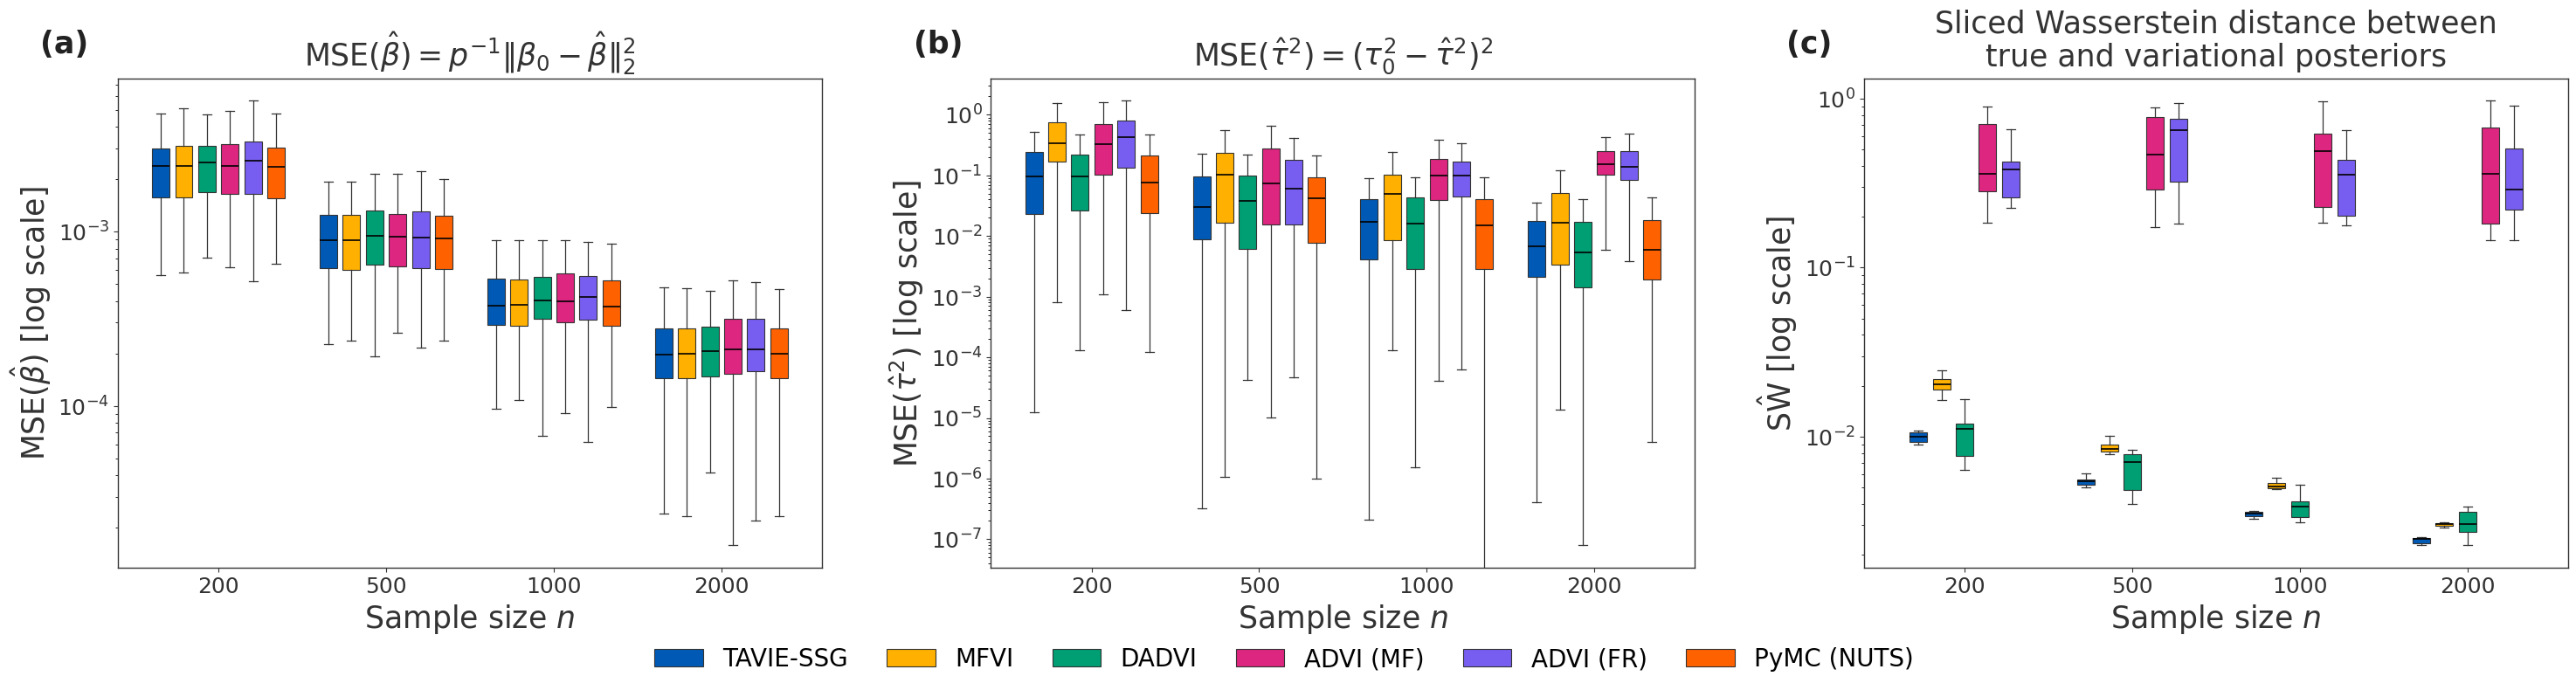

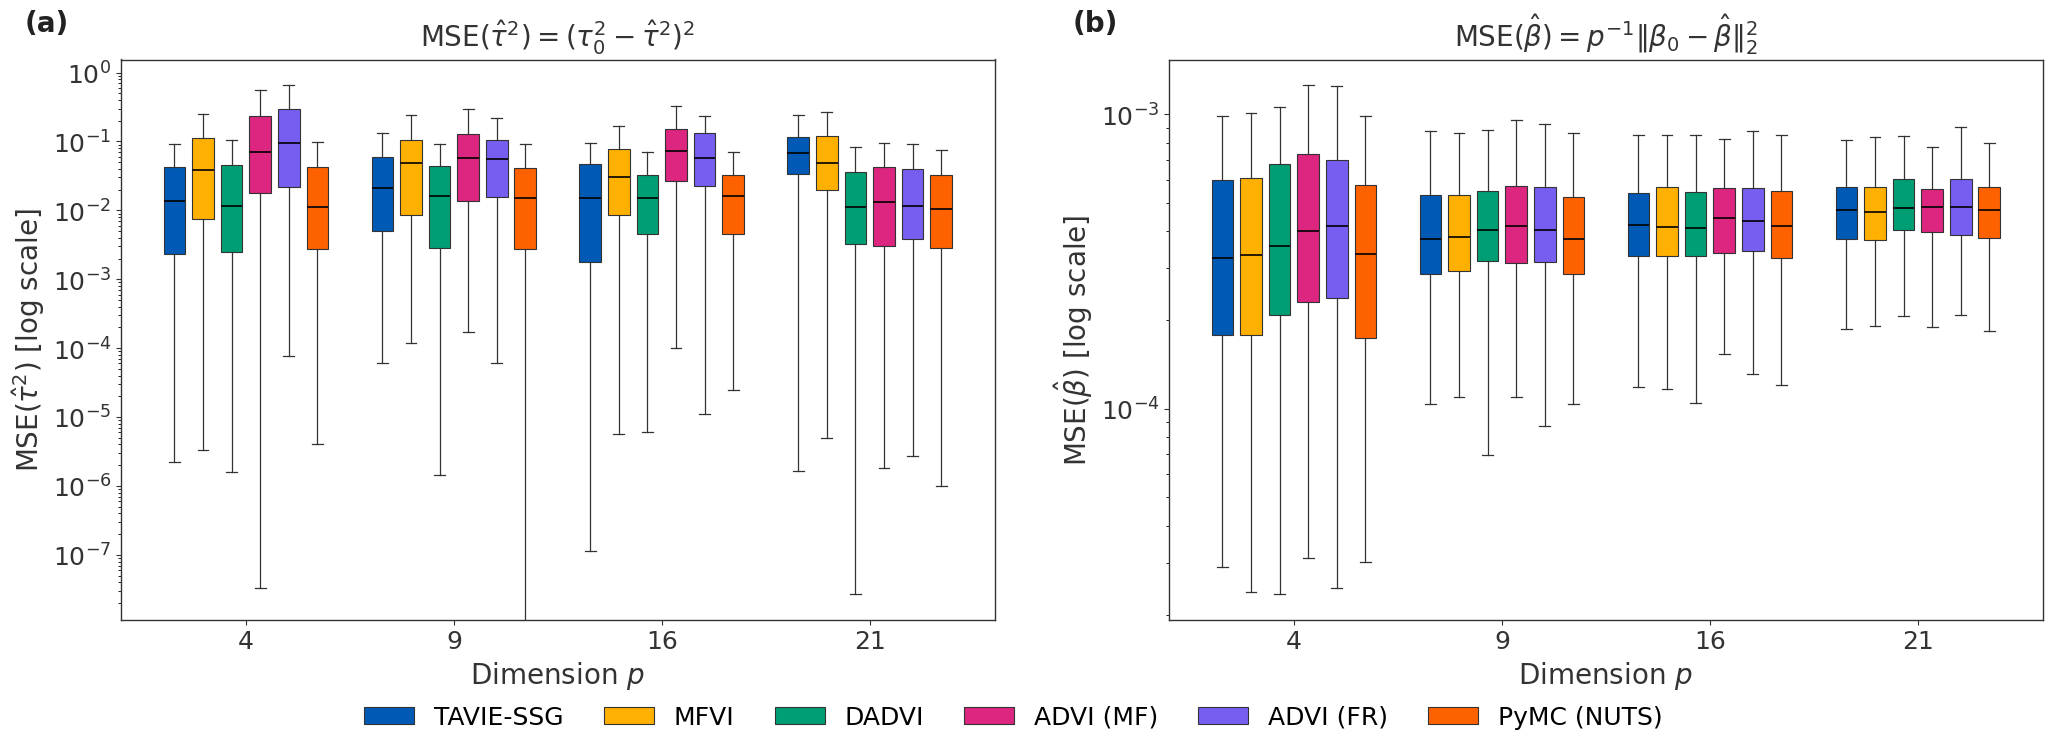

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# PATHS AND GLOBAL STYLE
# ============================================================

ROOT = Path.cwd()

assert (ROOT / "results_compete").exists(), (
    "Run final_figures.ipynb from the repository root."
)

OUTPUT_DIR = ROOT / "final_figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_5_PATH = OUTPUT_DIR / "figure_4_main.pdf"
FIGURE_6_PATH = OUTPUT_DIR / "figure_5_main.pdf"

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# SHARED METHOD ORDER AND COLORS
# ============================================================

METHODS = [
    "TAVIE-SSG",
    "MFVI",
    "DADVI",
    "ADVI (MF)",
    "ADVI (FR)",
    "PyMC (NUTS)",
]

METHOD_COLORS = {
    "TAVIE-SSG": "#005AB5",    # vivid royal blue
    "MFVI": "#FFB000",         # golden amber
    "DADVI": "#009E73",        # emerald green
    "ADVI (MF)": "#DC267F",    # vibrant magenta
    "ADVI (FR)": "#785EF0",    # electric violet
    "PyMC (NUTS)": "#FE6100",  # vivid orange
}

METRIC_KEYS = {
    "TAVIE-SSG": {
        "beta": "mse_beta_TAVIE",
        "tau2": "mse_tau2_TAVIE",
    },
    "MFVI": {
        "beta": "mse_beta_MFVI",
        "tau2": "mse_tau2_MFVI",
    },
    "DADVI": {
        "beta": "mse_beta_DADVI",
        "tau2": "mse_tau2_DADVI",
    },
    "ADVI (MF)": {
        "beta": "mse_beta_ADVI_mf",
        "tau2": "mse_tau2_ADVI_mf",
    },
    "ADVI (FR)": {
        "beta": "mse_beta_ADVI_fr",
        "tau2": "mse_tau2_ADVI_fr",
    },
    "PyMC (NUTS)": {
        "beta": "mse_beta_NUTS",
        "tau2": "mse_tau2_NUTS",
    },
}


# ============================================================
# PLOTTING SETTINGS
# ============================================================

AXIS_COLOR = "#333333"

GROUP_SPACING = 2.4
METHOD_STEP = 0.33
BOX_WIDTH = 0.25

median_style = {
    "color": "black",
    "linewidth": 1.2,
}

whisker_style = {
    "color": AXIS_COLOR,
    "linewidth": 0.9,
}

cap_style = {
    "color": AXIS_COLOR,
    "linewidth": 0.9,
}


def style_axis(ax):
    ax.set_facecolor("white")

    ax.tick_params(
        axis="x",
        colors=AXIS_COLOR,
        labelsize=18,
    )

    ax.tick_params(
        axis="y",
        colors=AXIS_COLOR,
        labelsize=18,
    )

    for spine in ax.spines.values():
        spine.set_color(AXIS_COLOR)
        spine.set_linewidth(1.0)


def draw_grouped_boxplots(
    ax,
    arrays_by_method,
    methods,
    x_values,
):
    """
    Draw grouped boxplots for a collection of methods.

    arrays_by_method[method][i] must contain the replicate
    values for x_values[i].
    """
    number_of_groups = len(x_values)
    number_of_methods = len(methods)

    centers = (
        np.arange(number_of_groups)
        * GROUP_SPACING
    )

    for method_index, method in enumerate(methods):
        method_values = arrays_by_method[method]

        data = [
            np.asarray(method_values[i], dtype=float)
            for i in range(number_of_groups)
        ]

        positions = (
            centers
            + (
                method_index
                - (number_of_methods - 1) / 2
            )
            * METHOD_STEP
        )

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=BOX_WIDTH,
            patch_artist=True,
            showfliers=False,
            medianprops=median_style,
            whiskerprops=whisker_style,
            capprops=cap_style,
        )

        for box in bp["boxes"]:
            box.set(
                facecolor=METHOD_COLORS[method],
                edgecolor=AXIS_COLOR,
                linewidth=0.8,
                alpha=1.0,
            )

    ax.set_xticks(centers)
    ax.set_xticklabels(x_values)

    ax.set_xlim(
        centers[0] - GROUP_SPACING * 0.60,
        centers[-1] + GROUP_SPACING * 0.60,
    )

    style_axis(ax)


def make_legend_handles(methods=METHODS):
    return [
        Patch(
            facecolor=METHOD_COLORS[method],
            edgecolor=AXIS_COLOR,
            linewidth=0.8,
            label=method,
        )
        for method in methods
    ]


# ============================================================
# FIGURE 4
# Fixed p = 9 (including intercept) and varying sample size n
# Panels: beta MSE, tau^2 MSE, sliced Wasserstein distance
# ============================================================

metrics_n = pd.read_pickle(
    ROOT
    / "results_compete"
    / "Student_metrics_multi_n_p_8.pkl"
)

sample_sizes = np.asarray(metrics_n["n"])
p_fixed = int(metrics_n["p"])

beta_arrays_n = {
    method: np.asarray(
        metrics_n[METRIC_KEYS[method]["beta"]]
    )
    for method in METHODS
}

tau2_arrays_n = {
    method: np.asarray(
        metrics_n[METRIC_KEYS[method]["tau2"]]
    )
    for method in METHODS
}


# ------------------------------------------------------------
# Load the sliced Wasserstein results
# ------------------------------------------------------------

sw_records = pd.read_pickle(
    ROOT
    / "results_compete"
    / "sw_student_compare_methods_alpha_1.0_p_8.pkl"
)

sw_results = pd.DataFrame(sw_records)

SW_KEY_MAP = {
    "TAVIE-SSG": "sw_TAVIE",
    "MFVI": "sw_MFVI",
    "DADVI": "sw_DADVI",
    "ADVI (MF)": "sw_ADVI_mf",
    "ADVI (FR)": "sw_ADVI_fr",
}

SW_METHODS = [
    "TAVIE-SSG",
    "MFVI",
    "DADVI",
    "ADVI (MF)",
    "ADVI (FR)",
]

sw_arrays_n = {}

for method in SW_METHODS:
    sw_key = SW_KEY_MAP[method]
    sw_arrays_n[method] = []

    for n_value in sample_sizes:
        values = sw_results.loc[
            sw_results["n"] == n_value,
            sw_key,
        ].dropna().to_numpy(dtype=float)

        # A logarithmic axis requires positive values.
        values = values[values > 0]

        sw_arrays_n[method].append(values)


# ------------------------------------------------------------
# Create Figure 4
# ------------------------------------------------------------

fig5, axes5 = plt.subplots(
    1,
    3,
    figsize=(30, 8),
    facecolor="white",
)


# Panel (a): beta MSE
draw_grouped_boxplots(
    ax=axes5[0],
    arrays_by_method=beta_arrays_n,
    methods=METHODS,
    x_values=sample_sizes,
)

axes5[0].set_yscale("log")

axes5[0].set_xlabel(
    r"Sample size $n$",
    fontsize=25,
    color=AXIS_COLOR,
)

axes5[0].set_ylabel(
    r"MSE($\hat{\beta}$) [log scale]",
    fontsize=25,
    color=AXIS_COLOR,
)

axes5[0].set_title(
    r"$\mathrm{MSE}(\hat{\beta})"
    r"=p^{-1}\|\beta_0-\hat{\beta}\|_2^2$",
    fontsize=25,
    color=AXIS_COLOR,
    pad=10,
)


# Panel (b): tau^2 MSE
draw_grouped_boxplots(
    ax=axes5[1],
    arrays_by_method=tau2_arrays_n,
    methods=METHODS,
    x_values=sample_sizes,
)

axes5[1].set_yscale("log")

axes5[1].set_xlabel(
    r"Sample size $n$",
    fontsize=25,
    color=AXIS_COLOR,
)

axes5[1].set_ylabel(
    r"MSE($\hat{\tau}^2$) [log scale]",
    fontsize=25,
    color=AXIS_COLOR,
)

axes5[1].set_title(
    r"$\mathrm{MSE}(\hat{\tau}^2)"
    r"=(\tau^2_0-\hat{\tau}^2)^2$",
    fontsize=25,
    color=AXIS_COLOR,
    pad=10,
)


# Panel (c): sliced Wasserstein distance
draw_grouped_boxplots(
    ax=axes5[2],
    arrays_by_method=sw_arrays_n,
    methods=SW_METHODS,
    x_values=sample_sizes,
)

axes5[2].set_yscale("log")

axes5[2].set_xlabel(
    r"Sample size $n$",
    fontsize=25,
    color=AXIS_COLOR,
)

axes5[2].set_ylabel(
    r"$\hat{\mathrm{SW}}$ [log scale]",
    fontsize=25,
    color=AXIS_COLOR,
)

axes5[2].set_title(
    "Sliced Wasserstein distance between\n"
    "true and variational posteriors",
    fontsize=25,
    color=AXIS_COLOR,
    pad=10,
)


# ------------------------------------------------------------
# Figure 4 panel labels
# ------------------------------------------------------------

for ax, panel_label in zip(
    axes5,
    ["(a)", "(b)", "(c)"],
):
    ax.text(
        -0.11,
        1.04,
        panel_label,
        transform=ax.transAxes,
        fontsize=25,
        fontweight="bold",
        va="bottom",
        ha="left",
        color="#222222",
    )


# ------------------------------------------------------------
# Figure 4 shared legend
# ------------------------------------------------------------

fig5.legend(
    handles=make_legend_handles(),
    loc="lower center",
    ncol=len(METHODS),
    frameon=False,
    fontsize=20,
    bbox_to_anchor=(0.5, 0.0),
    columnspacing=1.6,
    handlelength=2.0,
)

fig5.subplots_adjust(
    left=0.055,
    right=0.99,
    top=0.88,
    bottom=0.18,
    wspace=0.24,
)

fig5.savefig(
    FIGURE_5_PATH,
    format="pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# ============================================================
# FIGURE 5
# Fixed n = 1000 and varying dimension p
# Panels: tau^2 MSE and beta MSE
# ============================================================

metrics_p = pd.read_pickle(
    ROOT
    / "results_compete"
    / "Student_metrics_multi_p_n_1000.pkl"
)

p_values = np.asarray(metrics_p["p"])
n_fixed = int(metrics_p["n"])

beta_arrays_p = {
    method: np.asarray(
        metrics_p[METRIC_KEYS[method]["beta"]]
    )
    for method in METHODS
}

tau2_arrays_p = {
    method: np.asarray(
        metrics_p[METRIC_KEYS[method]["tau2"]]
    )
    for method in METHODS
}


# ------------------------------------------------------------
# Create Figure 5
# ------------------------------------------------------------

fig6, axes6 = plt.subplots(
    1,
    2,
    figsize=(21, 8),
    facecolor="white",
)


# Panel (a): tau^2 MSE
draw_grouped_boxplots(
    ax=axes6[0],
    arrays_by_method=tau2_arrays_p,
    methods=METHODS,
    x_values=np.array(p_values)+1,
)

axes6[0].set_yscale("log")

axes6[0].set_xlabel(
    r"Dimension $p$",
    fontsize=20,
    color=AXIS_COLOR,
)

axes6[0].set_ylabel(
    r"MSE($\hat{\tau}^2$) [log scale]",
    fontsize=20,
    color=AXIS_COLOR,
)

axes6[0].set_title(
    r"$\mathrm{MSE}(\hat{\tau}^2)"
    r"=(\tau^2_0-\hat{\tau}^2)^2$",
    fontsize=20,
    color=AXIS_COLOR,
    pad=10,
)


# Panel (b): beta MSE
draw_grouped_boxplots(
    ax=axes6[1],
    arrays_by_method=beta_arrays_p,
    methods=METHODS,
    x_values=np.array(p_values)+1,
)

axes6[1].set_yscale("log")

axes6[1].set_xlabel(
    r"Dimension $p$",
    fontsize=20,
    color=AXIS_COLOR,
)

axes6[1].set_ylabel(
    r"MSE($\hat{\beta}$) [log scale]",
    fontsize=20,
    color=AXIS_COLOR,
)

axes6[1].set_title(
    r"$\mathrm{MSE}(\hat{\beta})"
    r"=p^{-1}\|\beta_0-\hat{\beta}\|_2^2$",
    fontsize=20,
    color=AXIS_COLOR,
    pad=10,
)


# ------------------------------------------------------------
# Figure 5 panel labels
# ------------------------------------------------------------

for ax, panel_label in zip(
    axes6,
    ["(a)", "(b)"],
):
    ax.text(
        -0.11,
        1.04,
        panel_label,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold",
        va="bottom",
        ha="left",
        color="#222222",
    )


# ------------------------------------------------------------
# Figure 5 shared legend
# ------------------------------------------------------------

fig6.legend(
    handles=make_legend_handles(),
    loc="lower center",
    ncol=len(METHODS),
    frameon=False,
    fontsize=18,
    bbox_to_anchor=(0.5, 0.015),
    columnspacing=1.6,
    handlelength=2.0,
)

fig6.subplots_adjust(
    left=0.075,
    right=0.99,
    top=0.88,
    bottom=0.18,
    wspace=0.20,
)

fig6.savefig(
    FIGURE_6_PATH,
    format="pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

### Figure 6a and 6b of the main manuscript

Figure 6(a): maximum absolute difference = 0.00589891
Figure 6(a): mean absolute difference = 0.00022564


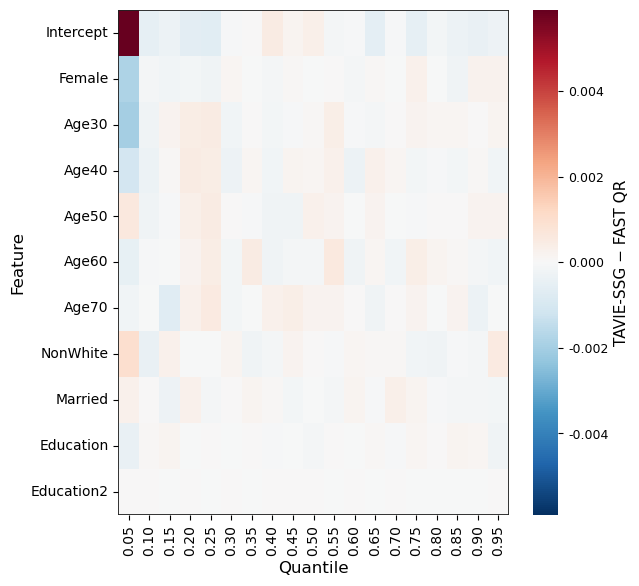

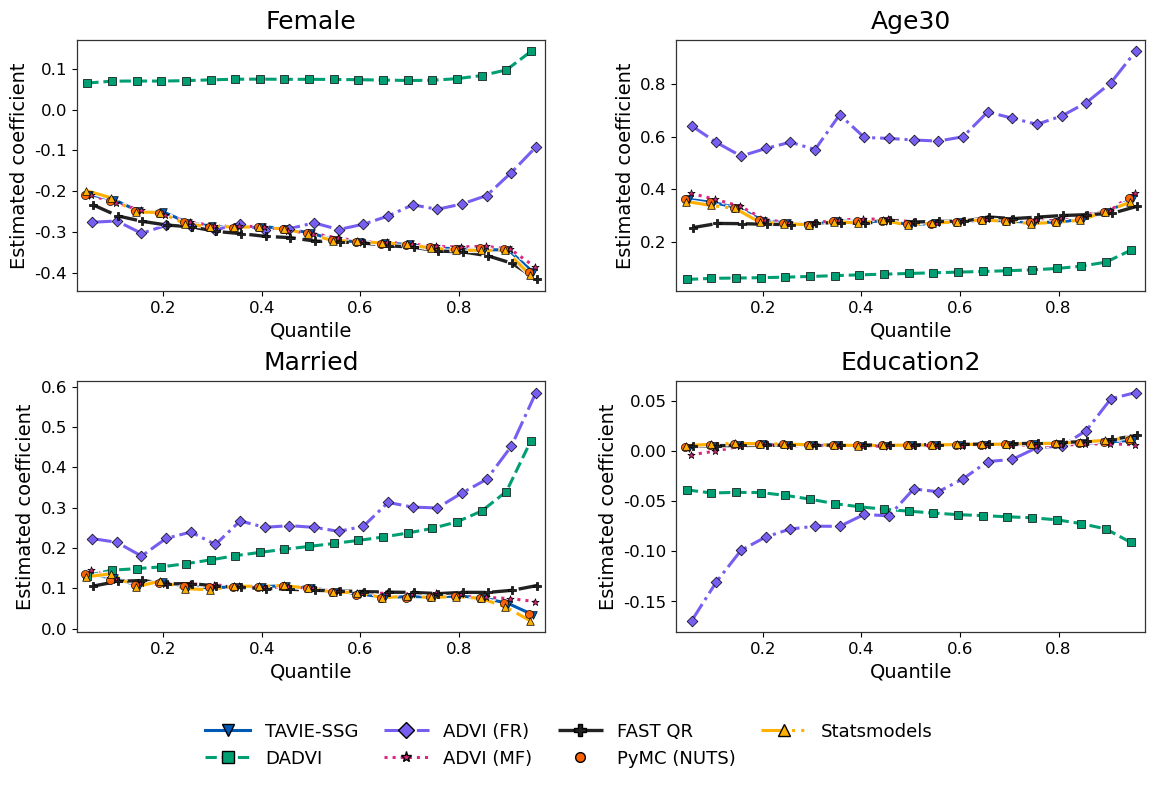

In [24]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from matplotlib.lines import Line2D
from matplotlib import patheffects as pe


# ============================================================
# PATHS AND GLOBAL STYLE
# ============================================================

ROOT = Path.cwd()

assert (ROOT / "results_data_study/census_QR").exists(), (
    "Run final_figures.ipynb from the repository root."
)

OUTPUT_DIR = ROOT / "final_figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_7A_PATH = OUTPUT_DIR / "figure_6a_main.pdf"
FIGURE_7B_PATH = OUTPUT_DIR / "figure_6b_main.pdf"

FULL_TAVIE_RESULTS_PATH = (
    ROOT
    / "results_data_study"
    / "census_QR"
    / "census_tavie_results_original_data_size_Python.pkl"
)

COMPETING_RESULTS_PATH = (
    ROOT
    / "results_data_study"
    / "census_QR"
    / "qr_results_all_n_1e4.pkl"
)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# LOAD SAVED RESULTS
# ============================================================

# Full-data TAVIE-SSG estimates used for Figure 7(a)
tavie_full_results = pd.read_pickle(
    FULL_TAVIE_RESULTS_PATH
)

tavie_full_mus = tavie_full_results["mus"]

# n = 10^4 competing-method results used for Figure 7(b).
# This file also contains the original full-data FAST QR estimates.
with open(COMPETING_RESULTS_PATH, "rb") as file:
    competing_results = pickle.load(file)

quantiles = np.asarray(
    competing_results["quantiles"],
    dtype=float,
)

feature_names = list(
    competing_results["feature_names"]
)

quantile_labels = [
    f"Quantile{quantile:.2f}"
    for quantile in quantiles
]


# ============================================================
# FIGURE 6(a)
# HEATMAP OF TAVIE-SSG MINUS FAST QR ESTIMATES
# ============================================================

# Reconstruct the FAST QR matrix:
# rows = features, columns = quantiles
fast_qr_matrix = np.column_stack([
    np.asarray(
        competing_results["FAST_QR_mus"][quantile],
        dtype=float,
    )
    for quantile in quantiles
])

fast_qr_df = pd.DataFrame(
    fast_qr_matrix,
    index=feature_names,
    columns=quantile_labels,
)

# Align the TAVIE DataFrame explicitly with FAST QR
tavie_heatmap_df = tavie_full_mus.loc[
    feature_names,
    quantile_labels,
]

difference_df = (
    tavie_heatmap_df
    - fast_qr_df
)

maximum_absolute_difference = (
    np.abs(difference_df.to_numpy()).max()
)

mean_absolute_difference = (
    np.abs(difference_df.to_numpy()).mean()
)

print(
    "Figure 6(a): maximum absolute difference = "
    f"{maximum_absolute_difference:.6g}"
)

print(
    "Figure 6(a): mean absolute difference = "
    f"{mean_absolute_difference:.6g}"
)


# ------------------------------------------------------------
# Draw Figure 6(a)
# ------------------------------------------------------------

fig7a, ax7a = plt.subplots(
    figsize=(6.3, 5.8),
    facecolor="white",
)

color_limit = (
    maximum_absolute_difference
    if maximum_absolute_difference > 0
    else 1.0
)

heatmap = sns.heatmap(
    difference_df,
    ax=ax7a,
    cmap="RdBu_r",
    center=0.0,
    vmin=-color_limit,
    vmax=color_limit,
    cbar_kws={
        "label": "TAVIE-SSG − FAST QR",
    },
)

display_quantile_labels = [
    f"{quantile:.2f}"
    for quantile in quantiles
]

ax7a.set_xticklabels(
    display_quantile_labels,
    rotation=90,
    fontsize=10,
)

ax7a.set_yticklabels(
    ax7a.get_yticklabels(),
    rotation=0,
    fontsize=10,
)

ax7a.set_xlabel(
    "Quantile",
    fontsize=12,
)

ax7a.set_ylabel(
    "Feature",
    fontsize=12,
)

ax7a.tick_params(
    axis="both",
    which="major",
    labelsize=10,
)

# Style the colorbar
colorbar = heatmap.collections[0].colorbar

colorbar.ax.tick_params(
    labelsize=9,
)

colorbar.set_label(
    "TAVIE-SSG − FAST QR",
    fontsize=11,
)

# Add a black border around the full heatmap
number_of_rows, number_of_columns = difference_df.shape

heatmap_border = patches.Rectangle(
    (0, 0),
    number_of_columns,
    number_of_rows,
    linewidth=1.3,
    edgecolor="#222222",
    facecolor="none",
)

ax7a.add_patch(heatmap_border)

fig7a.tight_layout(pad=0.5)

fig7a.savefig(
    FIGURE_7A_PATH,
    format="pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# ============================================================
# FIGURE 6(b)
# SELECTED CENSUS COEFFICIENTS ACROSS QUANTILES
# ============================================================

SELECTED_FEATURES = [
    "Female",
    "Age30",
    "Married",
    "Education2",
]

selected_feature_indices = [
    feature_names.index(feature)
    for feature in SELECTED_FEATURES
]


# ------------------------------------------------------------
# Convert each method's dictionary into a matrix
#
# Matrix dimensions:
# rows    = quantiles
# columns = coefficients/features
# ------------------------------------------------------------

METHOD_RESULT_KEYS = {
    "TAVIE-SSG": "TAVIE_mus",
    "DADVI": "DADVI_mus",
    "ADVI (FR)": "ADVI_fr_mus",
    "ADVI (MF)": "ADVI_mf_mus",
    "FAST QR": "FAST_QR_mus",
    "PyMC (NUTS)": "NUTS_mus",
    "Statsmodels": "SM_mus",
}

method_matrices = {}

for method, result_key in METHOD_RESULT_KEYS.items():
    method_dictionary = competing_results[result_key]

    method_matrices[method] = np.vstack([
        np.asarray(
            method_dictionary[quantile],
            dtype=float,
        )
        for quantile in quantiles
    ])


# ============================================================
# METHOD STYLES
# ============================================================

METHOD_STYLES = {
    "TAVIE-SSG": {
        "color": "#005AB5",
        "linestyle": "-",
        "marker": "v",
        "linewidth": 2.2,
        "jitter": 0.000,
    },
    "DADVI": {
        "color": "#009E73",
        "linestyle": "--",
        "marker": "s",
        "linewidth": 2.2,
        "jitter": -0.004,
    },
    "ADVI (FR)": {
        "color": "#785EF0",
        "linestyle": "-.",
        "marker": "D",
        "linewidth": 2.2,
        "jitter": 0.006,
    },
    "ADVI (MF)": {
        "color": "#DC267F",
        "linestyle": ":",
        "marker": "*",
        "linewidth": 2.2,
        "jitter": 0.004,
    },
    "FAST QR": {
        "color": "#222222",
        "linestyle": (0, (6, 2)),
        "marker": "P",
        "linewidth": 2.4,
        "jitter": 0.008,
    },
    "PyMC (NUTS)": {
        "color": "#FE6100",
        "linestyle": None,
        "marker": "o",
        "linewidth": 0.0,
        "jitter": -0.008,
    },
    "Statsmodels": {
        "color": "#FFB000",
        "linestyle": (0, (8, 2, 1, 2, 1, 2)),
        "marker": "^",
        "linewidth": 2.2,
        "jitter": -0.006,
    },
}

METHOD_ORDER = [
    "TAVIE-SSG",
    "DADVI",
    "ADVI (FR)",
    "ADVI (MF)",
    "FAST QR",
    "PyMC (NUTS)",
    "Statsmodels",
]

line_outline = [
    pe.Stroke(
        linewidth=4.0,
        foreground="white",
        alpha=0.90,
    ),
    pe.Normal(),
]


# ------------------------------------------------------------
# Create Figure 6(b)
# ------------------------------------------------------------

fig7b, axes7b = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    facecolor="white",
)

axes7b = axes7b.ravel()

for panel_index, feature_index in enumerate(
    selected_feature_indices
):
    ax = axes7b[panel_index]
    feature = feature_names[feature_index]

    for method in METHOD_ORDER:
        style = METHOD_STYLES[method]
        estimates = method_matrices[method][:, feature_index]

        x_values = (
            quantiles
            + style["jitter"]
        )

        if method == "PyMC (NUTS)":
            # PyMC (NUTS) is shown with markers only
            ax.scatter(
                x_values,
                estimates,
                color=style["color"],
                marker=style["marker"],
                s=34,
                alpha=0.95,
                zorder=5,
                linewidths=0.5,
                edgecolors="black",
            )

        else:
            ax.plot(
                x_values,
                estimates,
                linestyle=style["linestyle"],
                color=style["color"],
                linewidth=style["linewidth"],
                zorder=3,
                path_effects=line_outline,
            )

            ax.scatter(
                x_values,
                estimates,
                color=style["color"],
                marker=style["marker"],
                s=30,
                alpha=1.0,
                zorder=5,
                edgecolors="black",
                linewidths=0.5,
            )

    ax.set_title(
        feature,
        fontsize=18,
        pad=8,
    )

    ax.set_xlabel(
        "Quantile",
        fontsize=14,
    )

    ax.set_ylabel(
        "Estimated coefficient",
        fontsize=14,
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=12,
    )

    ax.set_xlim(
        quantiles.min() - 0.025,
        quantiles.max() + 0.025,
    )

    for spine in ax.spines.values():
        spine.set_color("#333333")
        spine.set_linewidth(0.9)


# ============================================================
# SHARED FIGURE 6(b) LEGEND
# ============================================================

legend_handles = []

for method in METHOD_ORDER:
    style = METHOD_STYLES[method]

    if method == "PyMC (NUTS)":
        handle = Line2D(
            [0],
            [0],
            marker=style["marker"],
            color="none",
            markerfacecolor=style["color"],
            markeredgecolor="black",
            markersize=7,
            linestyle="None",
            label=method,
        )

    else:
        handle = Line2D(
            [0],
            [0],
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markerfacecolor=style["color"],
            markeredgecolor="black",
            markersize=8,
            linewidth=max(
                style["linewidth"],
                1.5,
            ),
            label=method,
        )

    legend_handles.append(handle)

fig7b.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=13,
    bbox_to_anchor=(0.5, 0.01),
    columnspacing=1.4,
    handlelength=2.5,
)

fig7b.subplots_adjust(
    left=0.09,
    right=0.98,
    top=0.94,
    bottom=0.20,
    wspace=0.28,
    hspace=0.36,
)

fig7b.savefig(
    FIGURE_7B_PATH,
    format="pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

### Figure 7a and 7b of the main manuscript

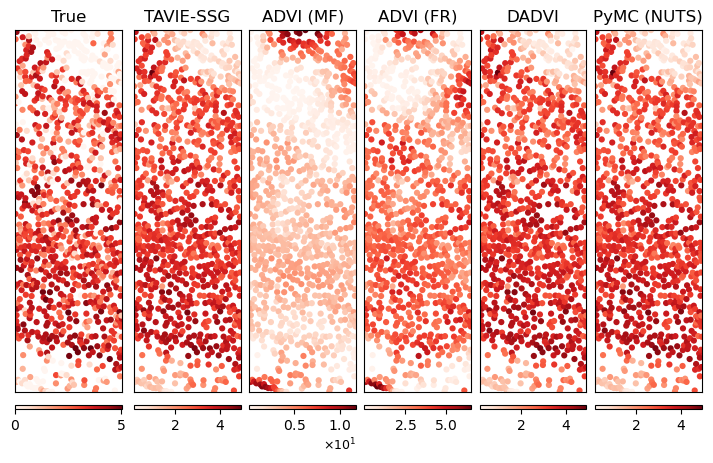

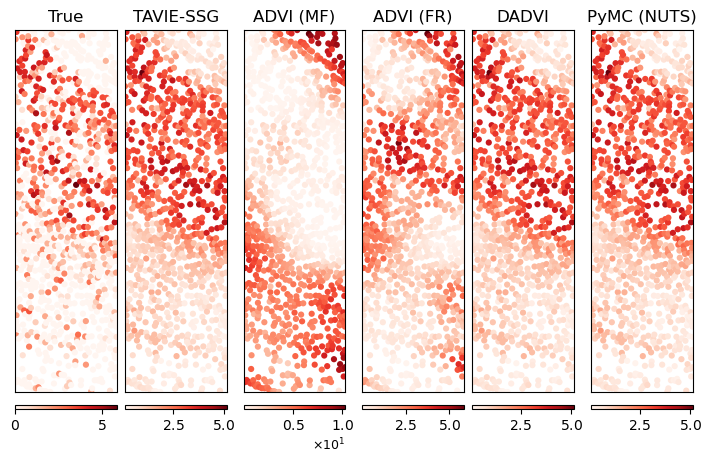

In [26]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# ============================================================
# PATHS AND GLOBAL STYLE
# ============================================================

ROOT = Path.cwd()

STARMAP_DATA_DIR = ROOT / "data" / "STArMAP"
STARMAP_RESULTS_DIR = (
    ROOT
    / "results_data_study"
    / "STARmap"
)

assert STARMAP_DATA_DIR.exists(), (
    "Run final_figures.ipynb from the repository root."
)

assert STARMAP_RESULTS_DIR.exists(), (
    "The saved STARmap results directory was not found."
)

OUTPUT_DIR = ROOT / "final_figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_8A_PATH = (
    OUTPUT_DIR
    / "figure_7a_main.pdf"
)

FIGURE_8B_PATH = (
    OUTPUT_DIR
    / "figure_7b_main.pdf"
)

RESULTS_PATH = (
    STARMAP_RESULTS_DIR
    / "all_results.pkl"
)

COUNT_PATH = (
    STARMAP_DATA_DIR
    / "dark_replicate_1.count.csv"
)

LOCATION_PATH = (
    STARMAP_DATA_DIR
    / "dark_replicate_1.loc.csv"
)

GENE_NAME_PATH = (
    STARMAP_DATA_DIR
    / "dark_replicate_1.gene_symbol.csv"
)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# LOAD THE ORIGINAL STARMAP DATA
# ============================================================

# Spatial locations
locations = pd.read_csv(
    LOCATION_PATH
)

locations.columns = [
    "x",
    "y",
]

# Observed gene-expression counts
observed_counts = pd.read_csv(
    COUNT_PATH
)

# Gene names in the same order as the count columns
gene_names = (
    pd.read_csv(GENE_NAME_PATH)["x"]
    .astype(str)
    .tolist()
)

observed_counts.columns = gene_names

# Convert observed counts to a NumPy array
observed_counts_array = observed_counts.to_numpy(
    dtype=float
)


# ============================================================
# LOAD THE SAVED MODEL PREDICTIONS
# ============================================================

with open(RESULTS_PATH, "rb") as file:
    results = pickle.load(file)

predicted_counts = results["yhat"]

required_prediction_keys = [
    "TAVIE",
    "ADVI_MF",
    "ADVI_FR",
    "DADVI",
    "NUTS",
]

for key in required_prediction_keys:
    assert key in predicted_counts, (
        f"Missing prediction results for {key}."
    )

    assert predicted_counts[key].shape == observed_counts_array.shape, (
        f"Unexpected prediction shape for {key}: "
        f"{predicted_counts[key].shape}"
    )

assert len(locations) == observed_counts_array.shape[0]
assert len(gene_names) == observed_counts_array.shape[1]


# ============================================================
# METHODS DISPLAYED IN EACH FIGURE
# ============================================================

METHOD_NAMES = [
    "True",
    "TAVIE-SSG",
    "ADVI (MF)",
    "ADVI (FR)",
    "DADVI",
    "PyMC (NUTS)",
]


# ============================================================
# CONSTRUCT THE SIX EXPRESSION VECTORS FOR ONE GENE
# ============================================================

def get_gene_expression_data(gene_name):
    """
    Return the observed and predicted expression vectors for
    one gene.

    All values are transformed using log(1 + expression), as
    in STARmap.ipynb.
    """
    if gene_name not in gene_names:
        raise ValueError(
            f"Gene {gene_name!r} was not found."
        )

    gene_index = gene_names.index(gene_name)
    number_of_locations = observed_counts_array.shape[0]

    expression_matrix = np.zeros(
        (number_of_locations, len(METHOD_NAMES)),
        dtype=float,
    )

    expression_matrix[:, 0] = (
        observed_counts_array[:, gene_index]
    )

    expression_matrix[:, 1] = (
        predicted_counts["TAVIE"][:, gene_index]
    )

    expression_matrix[:, 2] = (
        predicted_counts["ADVI_MF"][:, gene_index]
    )

    expression_matrix[:, 3] = (
        predicted_counts["ADVI_FR"][:, gene_index]
    )

    expression_matrix[:, 4] = (
        predicted_counts["DADVI"][:, gene_index]
    )

    expression_matrix[:, 5] = (
        predicted_counts["NUTS"][:, gene_index]
    )

    # Numerical protection before applying log1p
    expression_matrix = np.clip(
        expression_matrix,
        a_min=0.0,
        a_max=None,
    )

    log_expression_matrix = np.log1p(
        expression_matrix
    )

    return pd.DataFrame(
        log_expression_matrix,
        columns=METHOD_NAMES,
    )


# ============================================================
# PLOTTING FUNCTION
# ============================================================

def plot_starmap_gene(
    gene_name,
    output_path,
    cmap="Reds",
    figsize=(7, 4.5),
    dpi=300,
):
    """
    Plot observed and predicted spatial expression for one gene.

    Each method receives its own color scale, matching
    common_cbar=False in STARmap.ipynb.
    """
    expression_data = get_gene_expression_data(
        gene_name
    )

    fig, axes = plt.subplots(
        1,
        6,
        figsize=figsize,
        facecolor="white",
        constrained_layout=True,
    )

    axes = np.asarray(axes).reshape(-1)

    spatial_x = locations["x"].to_numpy(
        dtype=float
    )

    spatial_y = locations["y"].to_numpy(
        dtype=float
    )

    for ax, method_name in zip(
        axes,
        METHOD_NAMES,
    ):
        expression = expression_data[
            method_name
        ].to_numpy(dtype=float)

        scatter = ax.scatter(
            spatial_x,
            spatial_y,
            c=expression,
            cmap=cmap,
            s=20,
            edgecolor="none",
        )

        ax.set_title(
            method_name,
            fontsize=12,
            pad=6,
        )

        # Reproduce the orientation in STARmap.ipynb.
        ax.set_xlim(
            spatial_x.min(),
            spatial_x.max(),
        )

        ax.set_ylim(
            spatial_y.min(),
            spatial_y.max(),
        )

        # Hide spatial coordinate labels and ticks.
        ax.set_xticks([])
        ax.set_yticks([])

        # Individual horizontal colorbar for each method.
        colorbar = fig.colorbar(
            scatter,
            ax=ax,
            orientation="horizontal",
            fraction=0.20,
            pad=0.03,
            aspect=30,
        )

        colorbar.formatter = ticker.ScalarFormatter(
            useMathText=True
        )

        colorbar.formatter.set_powerlimits(
            (0, 0)
        )

        colorbar.update_ticks()

        colorbar.ax.tick_params(
            labelsize=10,
        )

        colorbar.ax.xaxis.get_offset_text().set_fontsize(
            9
        )

    fig.savefig(
        output_path,
        format="pdf",
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()


# ============================================================
# FIGURE 7(a): Slc17a7
# Gene index 132 in STARmap.ipynb
# ============================================================

assert gene_names[132] == "Slc17a7"

plot_starmap_gene(
    gene_name="Slc17a7",
    output_path=FIGURE_8A_PATH,
    cmap="Reds",
    figsize=(7, 4.5),
    dpi=300,
)


# ============================================================
# FIGURE 7(b): Pcp4
# Gene index 102 in STARmap.ipynb
# ============================================================

assert gene_names[102] == "Pcp4"

plot_starmap_gene(
    gene_name="Pcp4",
    output_path=FIGURE_8B_PATH,
    cmap="Reds",
    figsize=(7, 4.5),
    dpi=300,
)